# Notebook 2 - Nelson-Siegel & NSS Curve Fitting

This notebook:
1. Implements the **Nelson-Siegel (NS)** model with 3 factors (β₁, β₂, β₃)
2. Implements the **Nelson-Siegel-Svensson (NSS)** extension with 4 factors
3. Fits both models to every historical observation date
4. Computes reconstruction RMSE for benchmarking against VAE
5. Saves latent factors time series for P-measure analysis

**Note**: The paper encodes *swap rates* directly (not zero rates). We fit NS/NSS to swap rates 
as an approximation, which is standard practice and consistent with the paper's approach of 
comparing reconstruction error at the swap rate level.

## 0 - Imports

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from typing import NamedTuple
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

Path("figs").mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


## 1 - Configuration & Data

In [17]:
with open("clean_swap_data.pkl", "rb") as f:
    data = pickle.load(f)

In [18]:
swap_aligned = data["swap_aligned"]       
TARGET_TENORS = data["target_tenors"]

swap_data_fit = swap_aligned
TENORS = np.array(TARGET_TENORS, dtype=float)

BP_PER_UNIT = 10000.0  # internal convention : rates are decimals 

In [19]:
print("Dataset used: swap_aligned")
for ccy, df in swap_data_fit.items():
    print(f"  {ccy}: {df.shape[0]} obs × {df.shape[1]} tenors")

Dataset used: swap_aligned
  GBP: 712 obs × 7 tenors
  EUR: 712 obs × 7 tenors
  USD: 712 obs × 7 tenors
  JPY: 712 obs × 7 tenors


## 2 - Nelson-Siegel basis functions 

### Nelson-Siegel formula :
$$R(\tau) = \beta_1 + \beta_2 \left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}\right) + \beta_3 \left(\frac{1-e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right)$$

In [20]:
def ns_basis(tau: np.ndarray, lam: float) -> np.ndarray:
    """
    Compute Nelson-Siegel basis functions for given maturities.
    
    Parameters
    ----------
    tau : array of maturities in years
    lam : decay parameter (lambda)
    
    Returns
    -------
    B : (len(tau), 3) matrix of basis function values
        B[:,0] = 1                             (level)
        B[:,1] = (1 - exp(-lam*tau))/(lam*tau)  (slope)
        B[:,2] = B[:,1] - exp(-lam*tau)         (curvature)
    """
    tau = np.asarray(tau, dtype=float)
    lt = lam * tau
    with np.errstate(divide="ignore", invalid="ignore"): # Avoid division by zero for tau=0
        f1 = np.where(lt > 1e-10, (1.0 - np.exp(-lt)) / lt, 1.0)
    f2 = f1 - np.exp(-lt)
    return np.column_stack([np.ones_like(tau), f1, f2]) # [β1: level, β2: slope, β3: curvature]


In [21]:
def nss_basis(tau: np.ndarray, lam1: float, lam2: float) -> np.ndarray:
    """
    Nelson-Siegel-Svensson basis (4 factors).
    Adds a second hump term with its own decay parameter lam2.
    
    Returns
    -------
    B : (len(tau), 4) matrix
    """
    tau = np.asarray(tau, dtype=float)
    lt1 = lam1 * tau
    lt2 = lam2 * tau
    with np.errstate(divide="ignore", invalid="ignore"):
        f1 = np.where(lt1 > 1e-10, (1.0 - np.exp(-lt1)) / lt1, 1.0)
        g1 = f1 - np.exp(-lt1)
        f2 = np.where(lt2 > 1e-10, (1.0 - np.exp(-lt2)) / lt2, 1.0)
        g2 = f2 - np.exp(-lt2)
    return np.column_stack([np.ones_like(tau), f1, g1, g2]) # [β1: level, β2: slope, β3: curvature 1, β4: curvature 2]

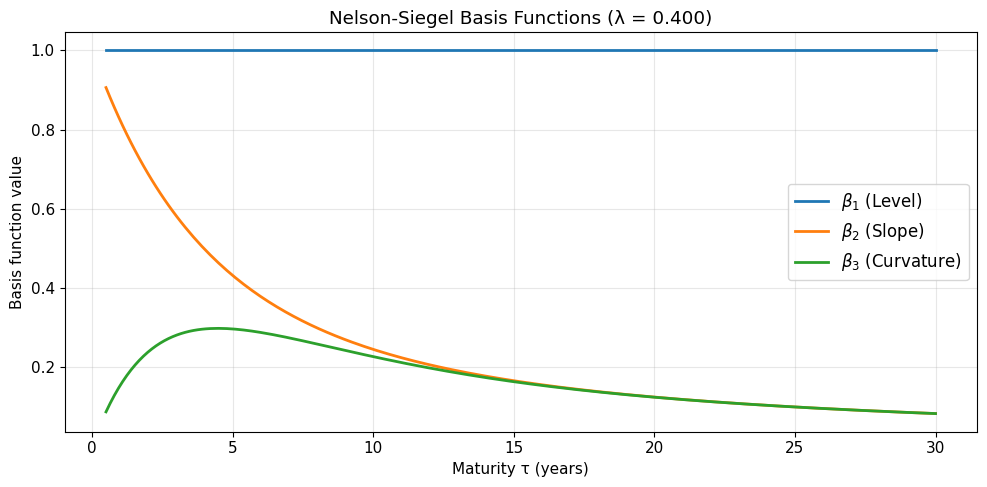

In [22]:
# Visualise NS basis à rechecker
tau_plot = np.linspace(0.5, 30, 200)
lam_default = 1.0 / 2.5
B_plot = ns_basis(tau_plot, lam_default)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [r"$\beta_1$ (Level)", r"$\beta_2$ (Slope)", r"$\beta_3$ (Curvature)"]
for i, label in enumerate(labels):
    ax.plot(tau_plot, B_plot[:, i], linewidth=2, label=label)
ax.set_xlabel("Maturity τ (years)")
ax.set_ylabel("Basis function value")
ax.set_title(f"Nelson-Siegel Basis Functions (λ = {lam_default:.3f})")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figs/fig_04_ns_basis.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 - Fitting procedure

For each observation date, we solve:
$$\min_{\beta_1, \beta_2, \beta_3} \sum_{n=1}^{N} (S_n - \hat{S}_n(\boldsymbol{\beta}, \lambda))^2$$

With λ fixed (as in Diebold-Li), this is a **linear least squares** problem.
We also implement a version where λ is jointly optimised (nonlinear).

In [23]:
class NSResult(NamedTuple):
    beta: np.ndarray      # (3,) or (4,) factor loadings
    lam: float            # lambda (or lam1 for NSS)
    lam2: float           # lam2 for NSS, NaN for NS
    fitted: np.ndarray    # (N,) fitted swap rates
    residuals: np.ndarray # (N,) residuals
    rmse: float           # root mean square error (bp)
    
def fit_ns_linear(swap_rates: np.ndarray, tenors: np.ndarray, lam: float = 0.4) -> NSResult:
    """
    Fit Nelson-Siegel with fixed lambda (linear least squares).
    """
    B = ns_basis(tenors, lam)
    # OLS: beta = (B'B)^{-1} B'y
    beta, *_ = np.linalg.lstsq(B, swap_rates, rcond=None)
    fitted = B @ beta
    resid = swap_rates - fitted
    rmse_bp = float(np.sqrt(np.mean(resid**2)) * BP_PER_UNIT)
    return NSResult(beta=beta, lam=lam, lam2=np.nan, fitted=fitted, residuals=resid, rmse=rmse_bp)


def fit_nss(swap_rates: np.ndarray, tenors: np.ndarray, lam1_init: float = 0.4, lam2_init: float = 0.1) -> NSResult:
    """
    Fit Nelson-Siegel-Svensson (4 factors) with jointly optimised lambdas.
    """
    def objective(params):
        lam1, lam2 = params
        if lam1 < 0.01 or lam1 > 5.0 or lam2 < 0.01 or lam2 > 5.0:
            return 1e10
        B = nss_basis(tenors, lam1, lam2)
        beta = np.linalg.lstsq(B, swap_rates, rcond=None)[0]
        fitted = B @ beta
        return np.sum((swap_rates - fitted)**2)

    res = minimize(
        objective,
        x0=[lam1_init, lam2_init],
        method="Nelder-Mead",
        options={"xatol": 1e-6, "fatol": 1e-10}
    )
    lam1_opt, lam2_opt = res.x
    B = nss_basis(tenors, lam1_opt, lam2_opt)
    beta = np.linalg.lstsq(B, swap_rates, rcond=None)[0]
    fitted = B @ beta
    resid = swap_rates - fitted
    rmse_bp = float(np.sqrt(np.mean(resid**2)) * BP_PER_UNIT)
    return NSResult(beta=beta, lam=lam1_opt, lam2=lam2_opt, fitted=fitted, residuals=resid, rmse=rmse_bp)

def fit_ens(swap_rates: np.ndarray, tenors: np.ndarray, lam_init: float = 0.4, lam_bounds: tuple[float, float] = (0.01, 5.0),) -> NSResult:
    """
    Extended Nelson-Siegel (eNS): NS with lambda optimised per date.
    We optimise lambda (1D) and compute beta by OLS conditional on lambda.
    Internal rates are decimals, rmse returned in bp.
    """
    lo, hi = lam_bounds

    def objective(lam_array):
        lam = float(lam_array[0])
        if lam < lo or lam > hi:
            return 1e10
        B = ns_basis(tenors, lam)
        beta = np.linalg.lstsq(B, swap_rates, rcond=None)[0]
        resid = swap_rates - (B @ beta)
        return np.sum(resid**2)

    res = minimize(
        objective,
        x0=[lam_init],
        method="Nelder-Mead",
        options={"xatol": 1e-6, "fatol": 1e-10}
    )
    lam_opt = float(res.x[0])

    # final OLS fit with optimal lambda
    B = ns_basis(tenors, lam_opt)
    beta = np.linalg.lstsq(B, swap_rates, rcond=None)[0]
    fitted = B @ beta
    resid = swap_rates - fitted
    rmse_bp = float(np.sqrt(np.mean(resid**2)) * BP_PER_UNIT)

    return NSResult(beta=beta, lam=lam_opt, lam2=np.nan, fitted=fitted, residuals=resid, rmse=rmse_bp)

In [24]:
# Quick Test
test_rates = swap_data_fit["USD"].iloc[100].values.astype(float)
test_tenors = np.array(swap_data_fit["USD"].columns, dtype=float)
res_ns = fit_ns_linear(test_rates, test_tenors)
res_nss = fit_nss(test_rates, test_tenors)
res_ens = fit_ens(test_rates, test_tenors, lam_init=0.4)
print(f"NS  RMSE: {res_ns.rmse:.2f} bp   λ={res_ns.lam:.3f}")
print(f"eNS RMSE: {res_ens.rmse:.2f} bp   λ={res_ens.lam:.3f}")
print(f"NSS RMSE: {res_nss.rmse:.2f} bp   λ1={res_nss.lam:.3f}, λ2={res_nss.lam2:.3f}")

NS  RMSE: 6.84 bp   λ=0.400
eNS RMSE: 6.53 bp   λ=0.625
NSS RMSE: 0.53 bp   λ1=0.452, λ2=0.082


## 4 - Fit NS & NSS to all dates, all currencies

In [25]:
ns_results = {}
ens_results = {}
nss_results = {}

for ccy, df in swap_data_fit.items():
    print(f"\nFitting {ccy} ({len(df)} dates)")
    tenors = np.array(df.columns, dtype=float)

    ns_list, ens_list, nss_list = [], [], []

    for i in range(len(df)):
        rates = df.iloc[i].values.astype(float)

        ns_list.append(fit_ns_linear(rates, tenors, lam=0.4))  # λ=1/30mois mais ici on a que 2.5 ans donc a peu pres 0.4
        ens_list.append(fit_ens(rates, tenors, lam_init=0.4))
        nss_list.append(fit_nss(rates, tenors))

    ns_results[ccy] = ns_list
    ens_results[ccy] = ens_list
    nss_results[ccy] = nss_list

    ns_rmses = np.array([r.rmse for r in ns_list])
    ens_rmses = np.array([r.rmse for r in ens_list])
    nss_rmses = np.array([r.rmse for r in nss_list])

    print(f"  NS  - mean: {ns_rmses.mean():.2f} bp, median: {np.median(ns_rmses):.2f} bp, max: {ns_rmses.max():.2f} bp")
    print(f"  eNS - mean: {ens_rmses.mean():.2f} bp, median: {np.median(ens_rmses):.2f} bp, max: {ens_rmses.max():.2f} bp")
    print(f"  NSS - mean: {nss_rmses.mean():.2f} bp, median: {np.median(nss_rmses):.2f} bp, max: {nss_rmses.max():.2f} bp")


Fitting GBP (712 dates)
  NS  - mean: 2.54 bp, median: 2.46 bp, max: 4.46 bp
  eNS - mean: 2.32 bp, median: 2.30 bp, max: 4.19 bp
  NSS - mean: 0.44 bp, median: 0.36 bp, max: 2.56 bp

Fitting EUR (712 dates)
  NS  - mean: 6.69 bp, median: 6.81 bp, max: 11.69 bp
  eNS - mean: 5.25 bp, median: 5.58 bp, max: 10.86 bp
  NSS - mean: 1.01 bp, median: 0.83 bp, max: 8.97 bp

Fitting USD (712 dates)
  NS  - mean: 6.20 bp, median: 6.26 bp, max: 12.12 bp
  eNS - mean: 4.89 bp, median: 5.01 bp, max: 9.39 bp
  NSS - mean: 0.92 bp, median: 0.64 bp, max: 7.48 bp

Fitting JPY (712 dates)
  NS  - mean: 4.75 bp, median: 3.93 bp, max: 12.09 bp
  eNS - mean: 2.38 bp, median: 2.11 bp, max: 10.19 bp
  NSS - mean: 1.13 bp, median: 0.77 bp, max: 5.35 bp


## 5 - RMSE distribution (like Fig. 10 in the paper)

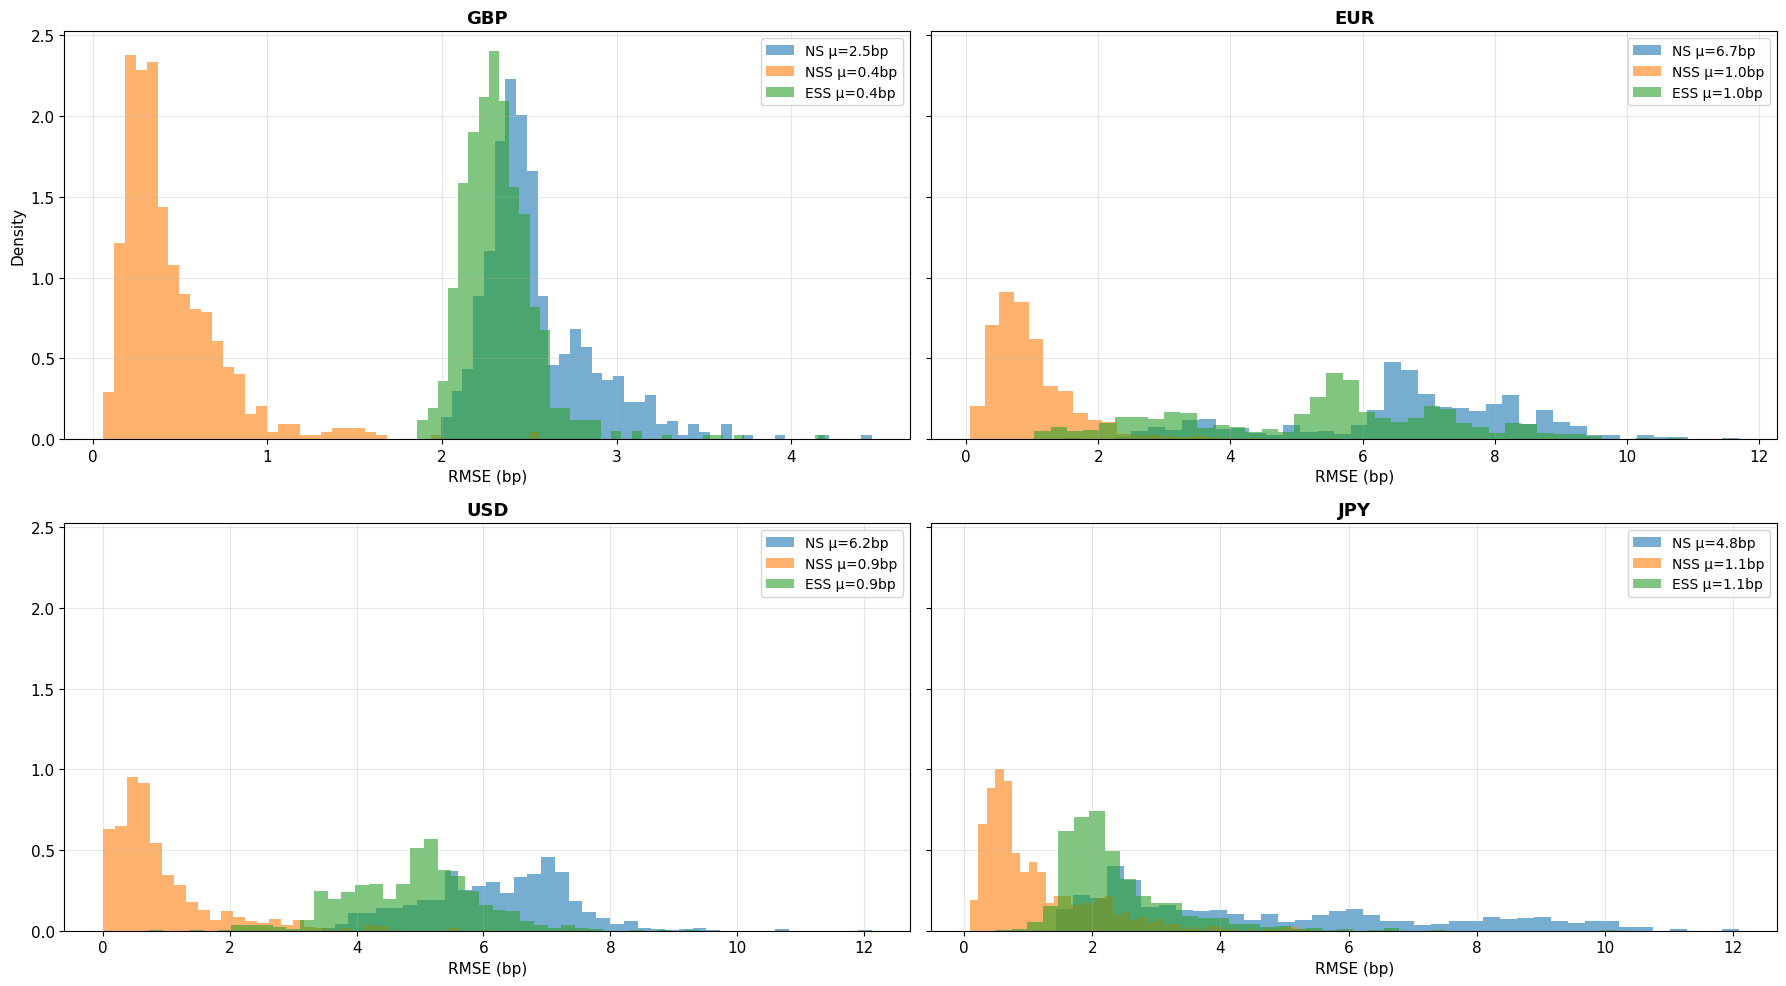

In [26]:
ccy_list = list(swap_data_fit.keys())
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for ax, ccy in zip(axes, ccy_list):
    ns_rmses = [r.rmse for r in ns_results[ccy]]
    ens_rmses = [r.rmse for r in ens_results[ccy]]
    nss_rmses = [r.rmse for r in nss_results[ccy]]

    ax.hist(ns_rmses, bins=40, alpha=0.6, label=f"NS μ={np.mean(ns_rmses):.1f}bp", density=True)
    ax.hist(nss_rmses, bins=40, alpha=0.6, label=f"NSS μ={np.mean(nss_rmses):.1f}bp", density=True)
    ax.hist(ens_rmses, bins=40, alpha=0.6, label=f"ESS μ={np.mean(nss_rmses):.1f}bp", density=True)

    ax.set_xlabel("RMSE (bp)")
    ax.set_title(ccy, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("figs/fig_05_ns_rmse_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 - Extract and plot NS latent factors (β₁, β₂, β₃)

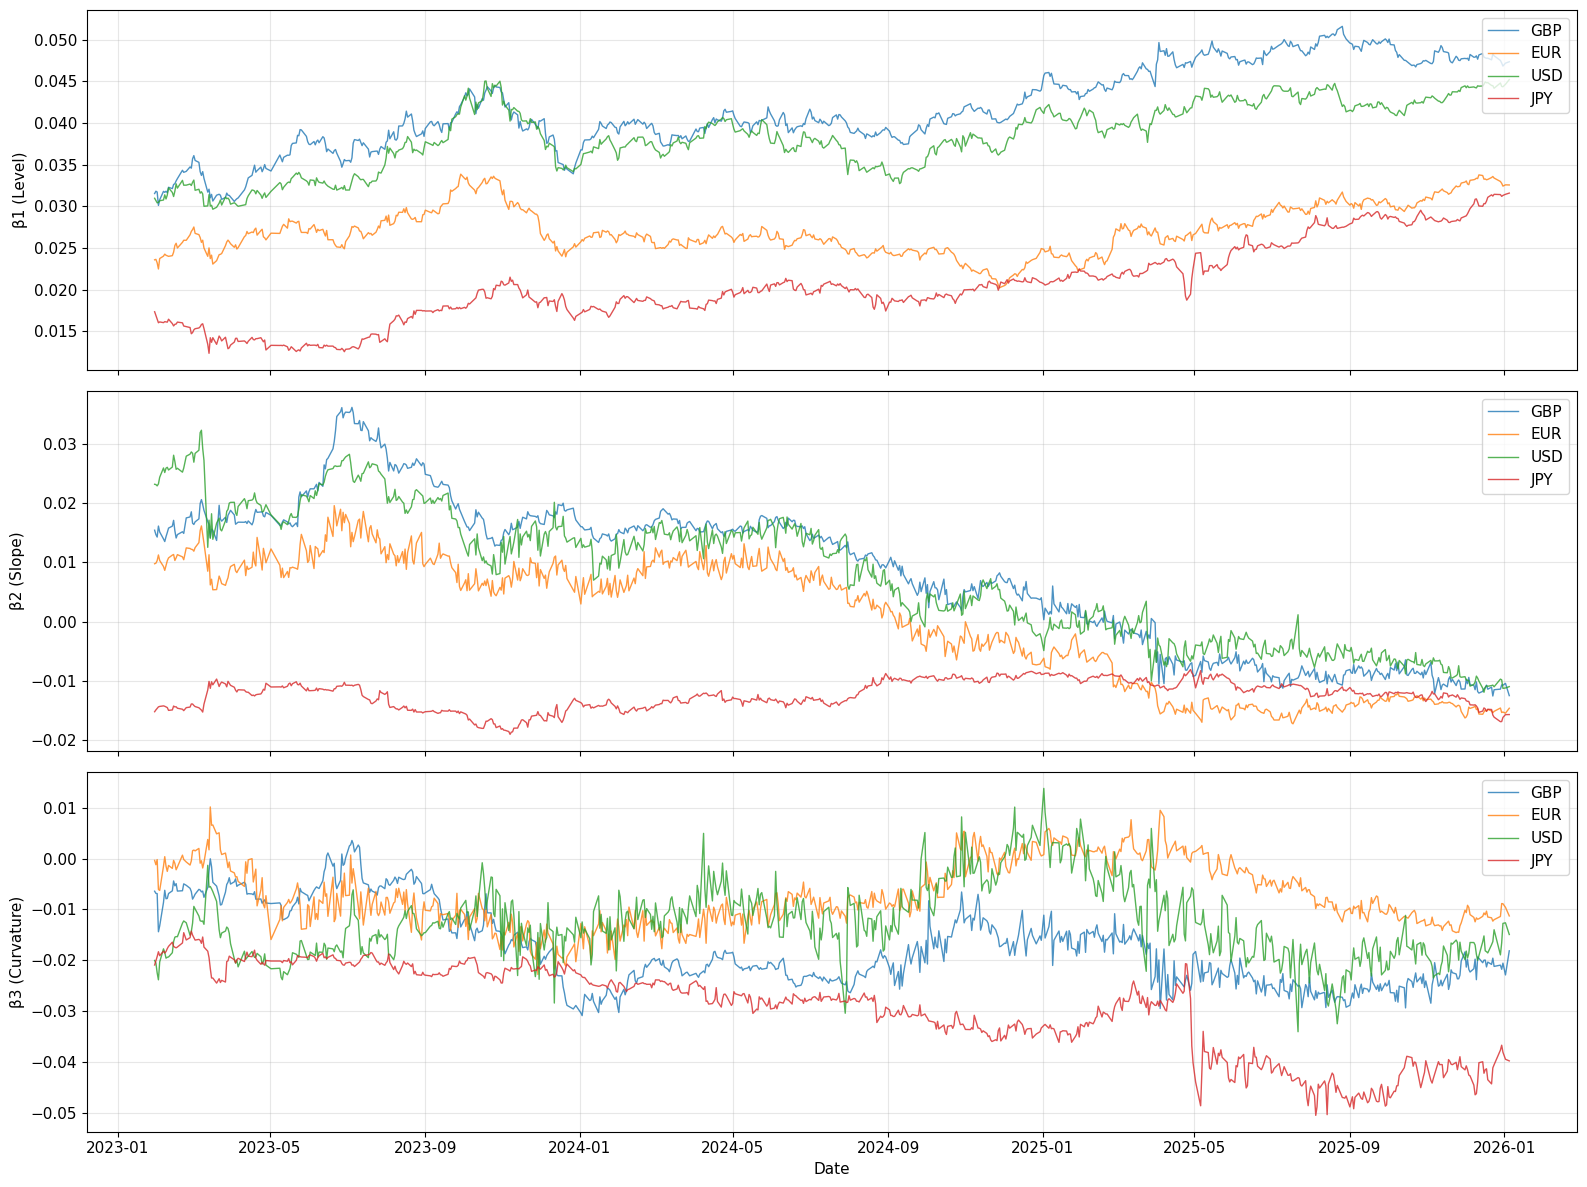

In [27]:
ns_factors = {}
for ccy, df in swap_data_fit.items():
    betas = np.array([r.beta for r in ns_results[ccy]])
    ns_factors[ccy] = pd.DataFrame(betas, index=df.index, columns=["β1", "β2", "β3"])

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
factor_names = ["β1 (Level)", "β2 (Slope)", "β3 (Curvature)"]

for i, (ax, fname) in enumerate(zip(axes, factor_names)):
    for ccy in ccy_list:
        ax.plot(ns_factors[ccy].index, ns_factors[ccy].iloc[:, i], label=ccy, linewidth=1.0, alpha=0.8)
    ax.set_ylabel(fname)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("figs/fig_06_ns_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - Example Fits

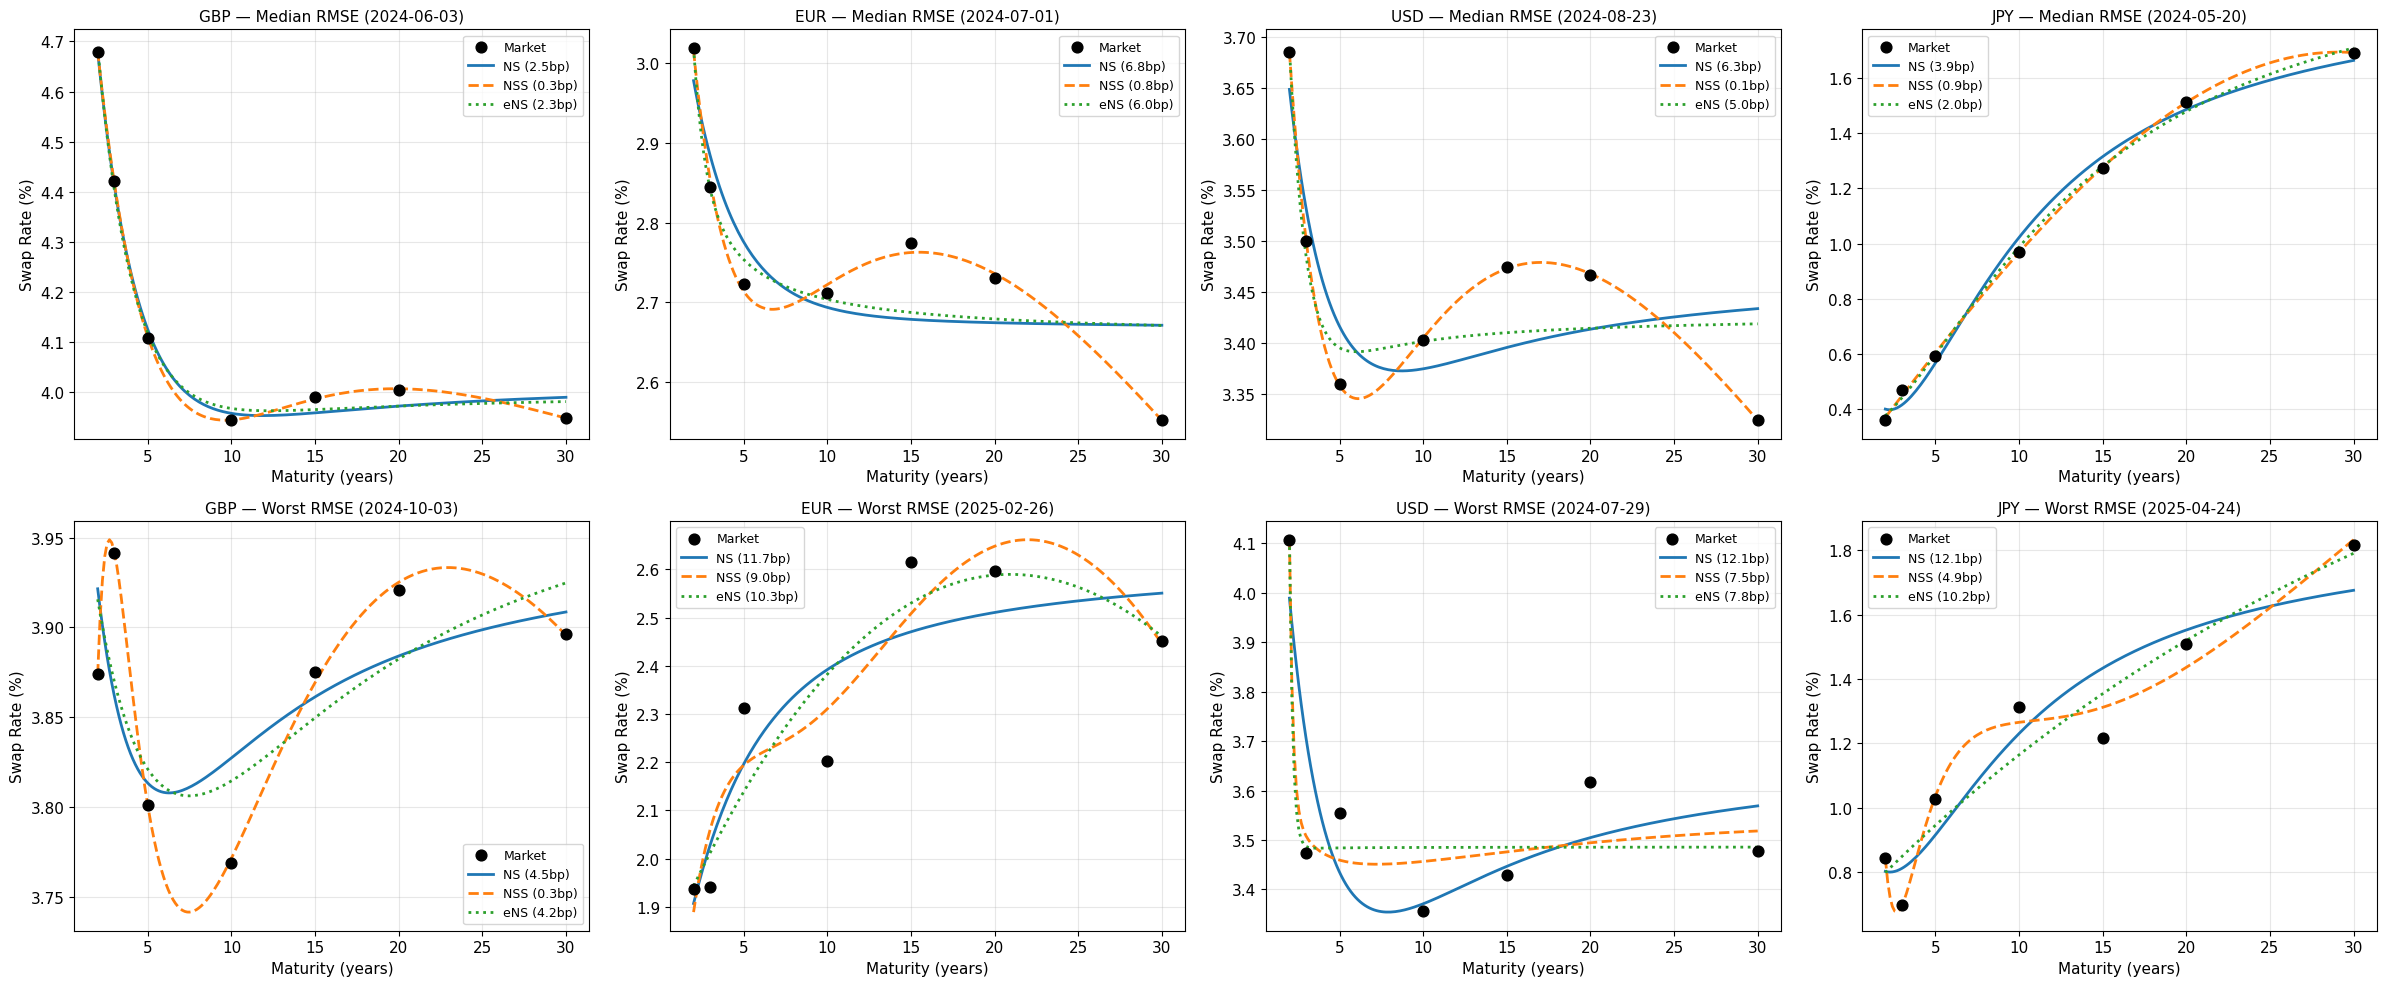

In [28]:
fig, axes = plt.subplots(2, len(ccy_list), figsize=(6*len(ccy_list), 10), squeeze=False)

for j, ccy in enumerate(ccy_list):
    df = swap_data_fit[ccy]
    tenors = np.array(df.columns, dtype=float)
    tau_fine = np.linspace(tenors.min(), tenors.max(), 200)

    rmses = np.array([r.rmse for r in ns_results[ccy]])
    idx_median = int(np.argsort(rmses)[len(rmses)//2])
    idx_worst = int(np.argmax(rmses))

    for row, idx, title in [(0, idx_median, "Median RMSE"), (1, idx_worst, "Worst RMSE")]:
        ax = axes[row, j]
        actual = df.iloc[idx].values.astype(float)

        res_ns = ns_results[ccy][idx]
        ns_fine = ns_basis(tau_fine, res_ns.lam) @ res_ns.beta

        res_nss = nss_results[ccy][idx]
        nss_fine = nss_basis(tau_fine, res_nss.lam, res_nss.lam2) @ res_nss.beta
        
        res_ens = ens_results[ccy][idx]
        ens_fine = ns_basis(tau_fine, res_ens.lam) @ res_ens.beta

        ax.scatter(tenors, 100*actual, s=60, zorder=5, color="black", label="Market")
        ax.plot(tau_fine, 100*ns_fine, linewidth=2, label=f"NS ({res_ns.rmse:.1f}bp)")
        ax.plot(tau_fine, 100*nss_fine, linewidth=2, linestyle="--", label=f"NSS ({res_nss.rmse:.1f}bp)")
        ax.plot(tau_fine, 100*ens_fine, linewidth=2, linestyle=":", label=f"eNS ({res_ens.rmse:.1f}bp)")
        
        ax.set_title(f"{ccy} — {title} ({df.index[idx].date()})", fontsize=11)
        ax.set_xlabel("Maturity (years)")
        ax.set_ylabel("Swap Rate (%)")
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figs/fig_07_ns_example_fits.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - In-sample / out-of-sample summary

In [29]:
split_year = 2025
rmse_summary = {}

for ccy, df in swap_data_fit.items():
    dates = df.index
    is_train = dates.year <= split_year

    ns_rmses  = np.array([r.rmse for r in ns_results[ccy]])
    ens_rmses = np.array([r.rmse for r in ens_results[ccy]])
    nss_rmses = np.array([r.rmse for r in nss_results[ccy]])

    rmse_summary[ccy] = {
        "ns_train_mean":  float(ns_rmses[is_train].mean()),
        "ns_test_mean":   float(ns_rmses[~is_train].mean()),
        "ens_train_mean": float(ens_rmses[is_train].mean()),
        "ens_test_mean":  float(ens_rmses[~is_train].mean()),
        "nss_train_mean": float(nss_rmses[is_train].mean()),
        "nss_test_mean":  float(nss_rmses[~is_train].mean()),
    }

rmse_table = pd.DataFrame(rmse_summary).T
print(rmse_table)

     ns_train_mean  ns_test_mean  ens_train_mean  ens_test_mean  \
GBP       2.541487      2.437731        2.322837       2.334156   
EUR       6.698226      3.702532        5.253400       3.056207   
USD       6.204897      4.071409        4.897593       3.487852   
JPY       4.741780      7.975088        2.375031       3.108112   

     nss_train_mean  nss_test_mean  
GBP        0.440984       0.587344  
EUR        1.014583       0.696798  
USD        0.919655       0.820178  
JPY        1.125616       2.355395  


## 9 - Save NS/NSS results

In [30]:
ens_lambdas = {
    ccy: pd.Series([r.lam for r in ens_results[ccy]], index=swap_data_fit[ccy].index, name="lambda_ens")
    for ccy in ccy_list
}

ns_output = {
    "ns_results": ns_results,
    "ens_results": ens_results,
    "nss_results": nss_results,
    "ns_factors": ns_factors,
    "ens_lambdas": ens_lambdas,
    "rmse_summary": rmse_summary,
    "split_year": split_year,
    "rates_in_decimal": True,
    "bp_per_unit": BP_PER_UNIT,
    "used_dataset": "swap_aligned",
}

with open("ns_results.pkl", "wb") as f:
    pickle.dump(ns_output, f)

print("Saved to ns_results.pkl")

Saved to ns_results.pkl
